# 32 — The γ phase transition: evidential lock-in

**Why this notebook exists (Plan P3).** The paper's §6 prediction in one line: a population
of honest active-inference agents *converges to the true structure at low γ, and undergoes a
phase transition into evidential lock-in as γ rises*, where

$$\gamma \;=\; \frac{\sum_{k\in\mathrm{dis}} \rho_k\,\mathbb 1[\rho_k\ \text{gated by the core}]}{\sum_{k\in\mathrm{dis}} \rho_k}$$

is the fraction of the **disconfirming** sensory precision the core's conviction field has
driven toward zero (Eq. 9). A channel held at $\rho_k\approx 0$ deposits *no* Fisher
information, so no amount of present, reachable evidence can move the belief along it — the
community "amputates its own correction channel."

In the code this is exactly `core_governance` with `precision_mode='derived'`: the derived
evidential gain is $\rho_k=\rho_{\max}/(1+g\,C_k)$, where $C_k$ is the channel's
coupling-to-core cost and $g=$ `core_governance`. We run it on the **relational** substrate
(nb30), so the channel γ silences is the very one that *moves structure* (the mass-balance
row).

**Setup.** We hold the world at the **oxygen (true) regime throughout** (`t_shift=0`) and
start the population on the **wrong** (phlogiston) paradigm: the truth is present and
reachable from step 0, and we ask whether the community reaches it or locks onto the falsehood.
The order parameter is $m(t)$ (population oxygen index): $\to 1$ if the population reaches
the truth, stalled near $0$ under lock-in.

In [1]:
%matplotlib inline
import sys, pathlib, dataclasses
ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(ROOT if (ROOT / 'src').exists() else ROOT.parent))
import numpy as np, jax
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

from src.config import NetworkConfig
from src.structural.phlogiston import StructuralConfig
from src.structural import step as S, shells, phlogiston as ph

NET = NetworkConfig(kind="watts_strogatz", mean_degree=4, rewiring_p=0.1)

def make_cfg(gov, prec=1.0, t_shift=0, n_steps=140, n_agents=48):
    return StructuralConfig(n_agents=n_agents, n_steps=n_steps, t_shift=t_shift,
        observation_operator="relational", precision_mode="derived",
        core_governance=gov, network=NET)

def run_m(gov, stance=None, prec=1.0, n_seeds=6, **kw):
    '''Seed-averaged m(t) trajectory (the population order parameter).'''
    cfg = make_cfg(gov, prec=prec, **kw)
    stance = cfg.mu_phlog_mass if stance is None else stance
    groups = [{"count": cfg.n_agents, "paradigm": "phlogiston", "stance": stance, "prec_scale": prec}]
    curves = []
    for s in range(n_seeds):
        ms, _ = S.run_trace(cfg, S.init_state(cfg, jax.random.PRNGKey(s), groups=groups))
        curves.append(np.asarray(ms))
    return np.mean(curves, axis=0)

print('substrate: relational · precision_mode: derived · γ knob: core_governance')

substrate: relational · precision_mode: derived · γ knob: core_governance


## §1 — The 1D transition and its mechanism

Left: seed-averaged final $m$ for the **wrong-start** population as we sweep γ — it reaches
the truth (high $m$) at low γ and **locks in** (low $m$) past a *sharp* threshold near
γ≈200. Right: the cause — the evidential precision $\rho$ on the disconfirming mass-balance
channel, $\rho_{\max}/(1+g\,C_k)$, driven toward zero over the same γ range. The belief
stops moving exactly because the channel that would refute it goes dark. The transition is
sharp (first-order-like): either the accumulated evidence overcomes the prior before the
channel is silenced, or it never does.

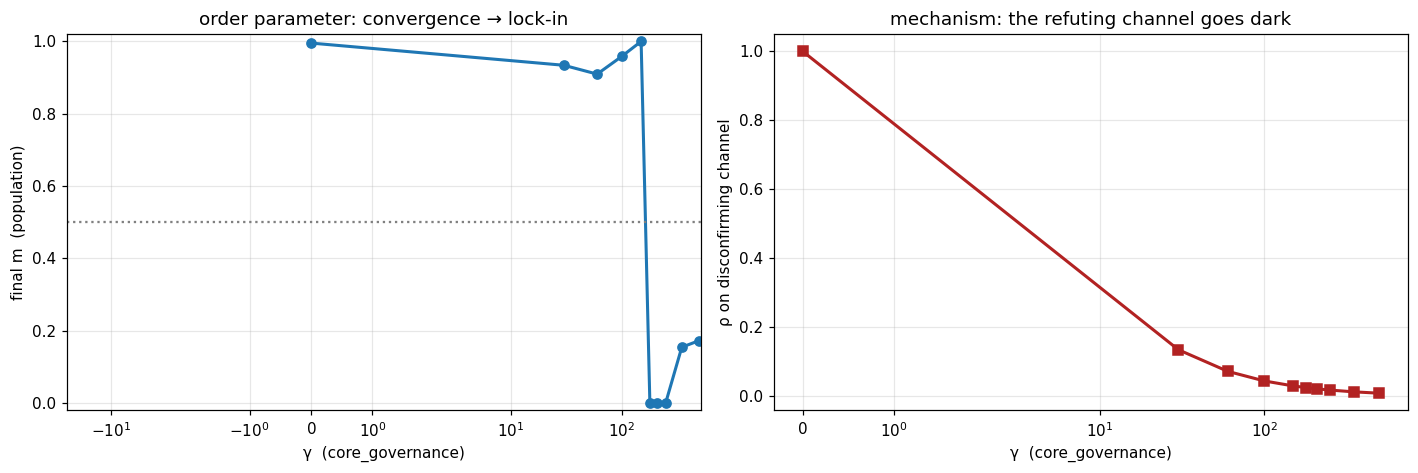

final m by γ: {0: 1.0, 30: 0.9300000071525574, 60: 0.9100000262260437, 100: 0.9599999785423279, 150: 1.0, 180: 0.0, 210: 0.0, 250: 0.0, 350: 0.15000000596046448, 500: 0.17000000178813934}
=> m collapses as ρ on the disconfirming channel → 0: evidential lock-in.


In [2]:
gammas = np.array([0, 30, 60, 100, 150, 180, 210, 250, 350, 500])
final_m = np.array([run_m(g, n_seeds=8)[-1] for g in gammas])   # start-wrong, world=oxygen

# rho on the disconfirming (mass-balance) row, the channel gamma silences:
rho_dis = []
for g in gammas:
    cfg = make_cfg(g)
    rho_dis.append(float(ph.derived_channel_precision(cfg)[-1]))   # last row = mass-balance
rho_dis = np.array(rho_dis)

fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 4.4))
a0.plot(gammas, final_m, 'o-', lw=2)
a0.axhline(0.5, color='grey', ls=':'); a0.set_xscale('symlog')
a0.set_xlabel('γ  (core_governance)'); a0.set_ylabel('final m  (population)')
a0.set_title('order parameter: convergence → lock-in'); a0.set_ylim(-0.02, 1.02)

a1.plot(gammas, rho_dis, 's-', color='firebrick', lw=2)
a1.set_xscale('symlog'); a1.set_xlabel('γ  (core_governance)')
a1.set_ylabel('ρ on disconfirming channel'); a1.set_title('mechanism: the refuting channel goes dark')
plt.tight_layout(); plt.savefig('figures_nb32_transition.png'); plt.show()
print('final m by γ:', dict(zip(gammas.tolist(), np.round(final_m, 2).tolist())))
print('=> m collapses as ρ on the disconfirming channel → 0: evidential lock-in.')

## §2 — The lock-in is a genuine bistability (two-IC basin control)

Is the stall real lock-in or just slow relaxation? We hold the world **fixed at the oxygen
(true) regime** (`t_shift=0`) and start the population from each pole — phlogiston (wrong)
and oxygen (right). At low γ both initial conditions converge to the truth (monostable). At
high γ they stay where they started: the phlogiston-start stalls on the wrong paradigm while
the oxygen-start holds the truth — **two absorbing states**, the signature of lock-in. The
truth is reachable (the oxygen-start proves it) yet the wrong-start never reaches it, because
its correction channel is silenced.

γ=    0: start-phlog→0.99  start-oxy→1.00  gap=0.00


γ=  400: start-phlog→0.17  start-oxy→1.00  gap=0.83


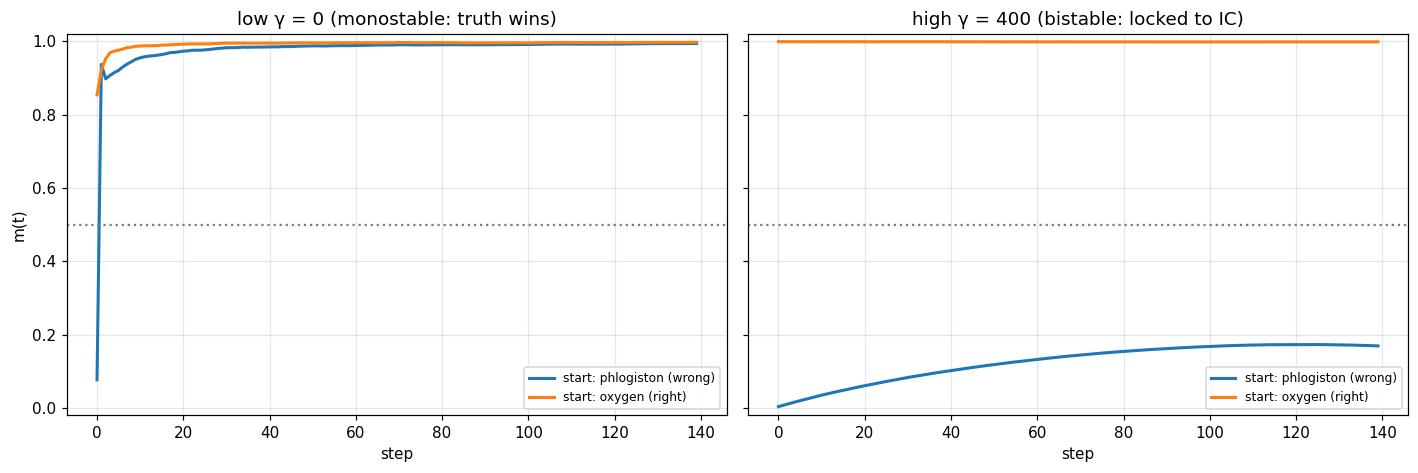

=> low γ: gap≈0 (monostable). high γ: gap≈0.9 (bistable evidential lock-in).


In [3]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
for ax, g, ttl in [(a0, 0.0, 'low γ = 0 (monostable: truth wins)'),
                   (a1, 400.0, 'high γ = 400 (bistable: locked to IC)')]:
    mp = run_m(g, stance=-1.0, t_shift=0)      # start phlogiston pole
    mo = run_m(g, stance=+1.0, t_shift=0)      # start oxygen pole
    ax.plot(mp, lw=2, label='start: phlogiston (wrong)')
    ax.plot(mo, lw=2, label='start: oxygen (right)')
    ax.axhline(0.5, color='grey', ls=':'); ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel('step'); ax.set_title(ttl); ax.legend(fontsize=8)
    print(f"γ={g:5.0f}: start-phlog→{mp[-1]:.2f}  start-oxy→{mo[-1]:.2f}  gap={mo[-1]-mp[-1]:.2f}")
a0.set_ylabel('m(t)')
plt.tight_layout(); plt.savefig('figures_nb32_bistable.png'); plt.show()
print('=> low γ: gap≈0 (monostable). high γ: gap≈0.9 (bistable evidential lock-in).')

## §3 — The phase diagram: γ × conservatism

The lock-in boundary in the (γ, conservatism) plane. Conservatism is the population's prior
precision scale (a stiff, entrenched core). It does **not** create a belt-first/core-last
staircase (nb31), but it *does* lower the γ threshold for lock-in: a stiffer core has a
larger coupling-to-core cost $C_k$, so the same γ silences its disconfirming channel more.
The boundary sweeps to lower γ as conservatism rises.

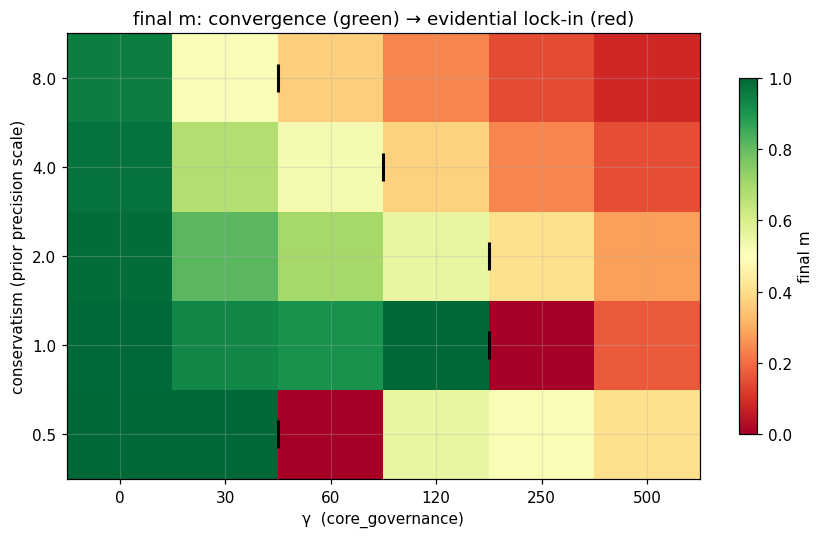

final-m grid (rows=conservatism, cols=γ):
[[1.   1.   0.   0.56 0.52 0.4 ]
 [0.99 0.93 0.91 1.   0.   0.17]
 [0.99 0.81 0.7  0.56 0.4  0.28]
 [0.97 0.67 0.52 0.37 0.24 0.15]
 [0.95 0.51 0.36 0.24 0.15 0.09]]
=> the lock-in front (black ticks) moves to LOWER γ as conservatism rises.


In [4]:
gam_axis = np.array([0, 30, 60, 120, 250, 500])
prec_axis = np.array([0.5, 1.0, 2.0, 4.0, 8.0])
M = np.zeros((len(prec_axis), len(gam_axis)))
for i, pr in enumerate(prec_axis):
    for j, g in enumerate(gam_axis):
        M[i, j] = run_m(g, prec=pr, n_seeds=5)[-1]

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(M, origin='lower', aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(gam_axis))); ax.set_xticklabels(gam_axis)
ax.set_yticks(range(len(prec_axis))); ax.set_yticklabels(prec_axis)
ax.set_xlabel('γ  (core_governance)'); ax.set_ylabel('conservatism (prior precision scale)')
ax.set_title('final m: convergence (green) → evidential lock-in (red)')
# mark the m=0.5 boundary per row
for i in range(len(prec_axis)):
    below = np.where(M[i] < 0.5)[0]
    if below.size:
        ax.plot(below[0] - 0.5, i, 'k|', markersize=18, markeredgewidth=2)
fig.colorbar(im, ax=ax, shrink=0.8, label='final m')
plt.tight_layout(); plt.savefig('figures_nb32_phase.png'); plt.show()
print('final-m grid (rows=conservatism, cols=γ):'); print(np.round(M, 2))
print('=> the lock-in front (black ticks) moves to LOWER γ as conservatism rises.')

## Verdict

The §6 headline reproduces on the corrected substrate. As γ rises the disconfirming channel
is silenced ($\rho\to 0$, §1) and the population stops converging; the two-IC control (§2)
shows the stall is a genuine **bistability** — honest agents with the truth reachable in
principle nonetheless lock onto the wrong paradigm, because the channel that would refute
them deposits no information. Conservatism does not stripe the dynamics into a staircase
(nb31) but it **lowers the γ threshold for lock-in** (§3): a stiffer core amputates its
correction channel at weaker conviction. This is the result the paper says distinguishes
structure learning from movement within a fixed menu — a community that has seen the anomaly
and not moved.

Next:
* **P4 (nb33)** — add the conviction field $U=\mathsf T u$ as a second, *balanced* field
  (the value source whose tilt is, formally, what produces γ), calibrated so neither it nor
  the evidence dominates;
* **P5 (nb34)** — vary the trust graph's algebraic connectivity and read the Zollman
  speed/accuracy transient (denser graphs reorganise faster but lose the diversity that
  protects against locking onto the worse paradigm).